# PU experiments

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from load_experiment import load_experiment_results 
import datetime 
from helpers import get_n_labels


In [2]:
EXPERIMENT = "c"

In [3]:
df = load_experiment_results(name=EXPERIMENT,n=0)
df = df[df["model"]!="oracle"]
# df["model"] = "classic"
df.model

0         classic
1           naive
3       two_model
4         classic
5           naive
          ...    
1913        naive
1915    two_model
1916      classic
1917        naive
1919    two_model
Name: model, Length: 1440, dtype: object

In [4]:
# df_old = load_experiment_results(name=EXPERIMENT,n=1)
# df_old = df_old[(df_old["model"]!="oracle") & (df_old["model"]!="classic")] 
# df_old = df_old[(df_old["dataset"]=="mnist")] 
# df = pd.concat([df_old,df],axis=0)
# df

In [5]:
df["precision"] = (df["0 precision"]+df["1 precision"]) / 2
df["recall"] = (df["0 recall"]+df["1 recall"]) / 2
df["f1"] = (df["0 f1"]+df["1 f1"]) / 2

df[["precision","recall","f1"]] = df[["precision","recall","f1"]].round(4)
df[["precision","recall","f1"]].describe()

,precision,recall,f1
count,1440.000000,1440.000000,1440.000000
mean,0.709517,0.722028,0.664580
std,0.248038,0.180407,0.242471
min,0.144000,0.138700,0.144500
25%,0.655375,0.514100,0.393700
50%,0.764500,0.712400,0.695500
75%,0.913250,0.908500,0.905300
max,1.000000,1.000000,1.000000


In [6]:
fig_experiment_folder = EXPERIMENT
os.makedirs(fig_experiment_folder, exist_ok=True)
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
fig_folder = os.path.join(fig_experiment_folder, f"{current_time}")
os.makedirs(fig_folder, exist_ok=True)

In [7]:
# df = df.loc[df[EXPERIMENT].isin([0.005,0.01,0.1,0.2,0.250.5,0.75,1])]

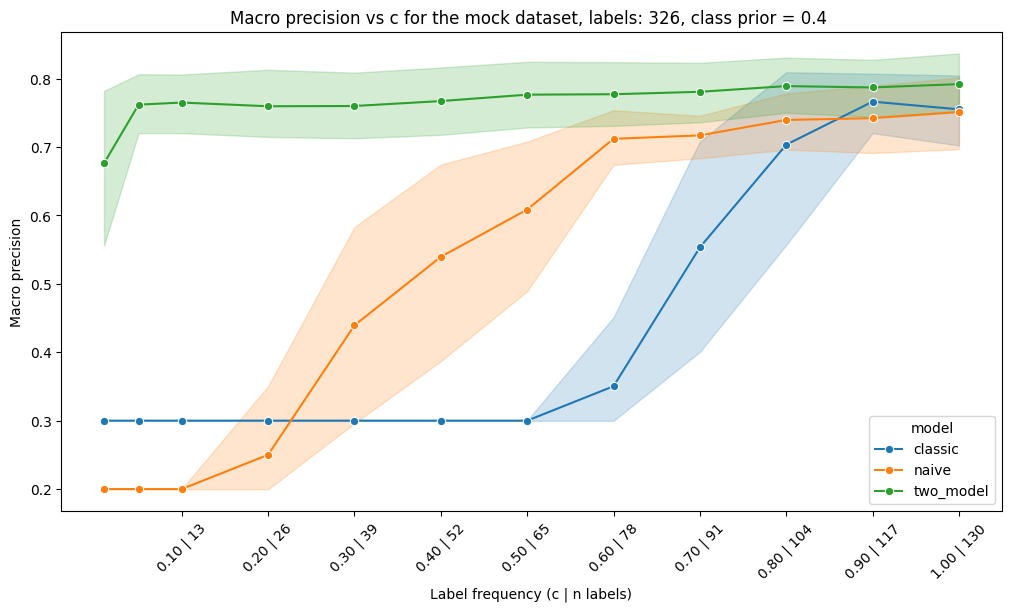

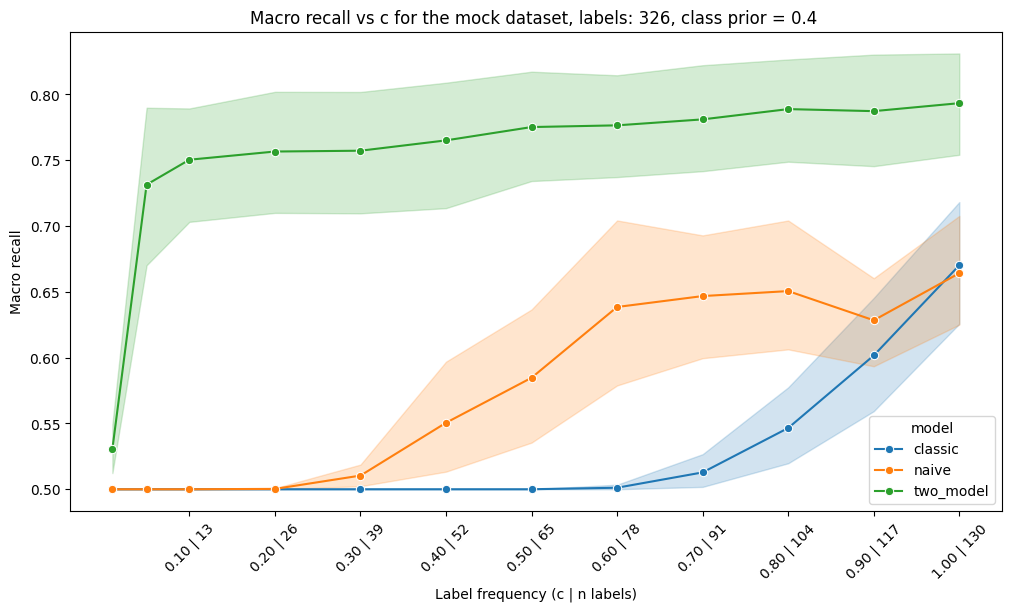

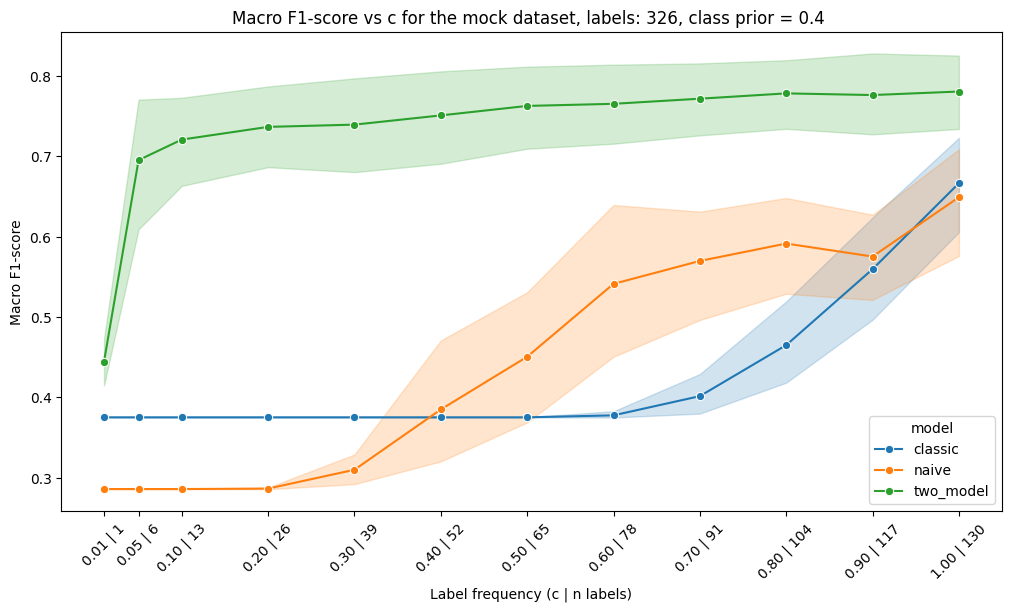

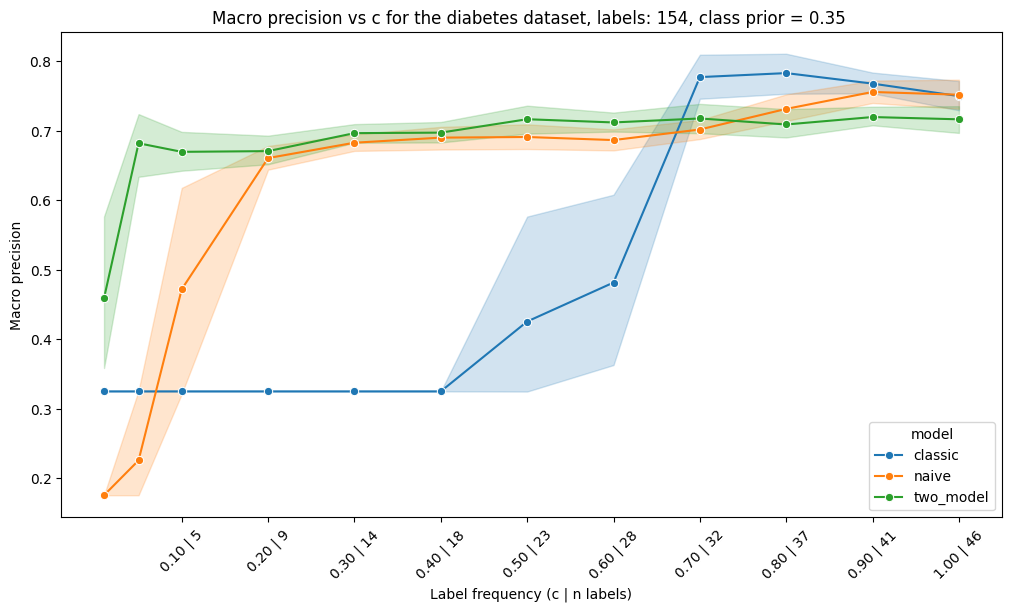

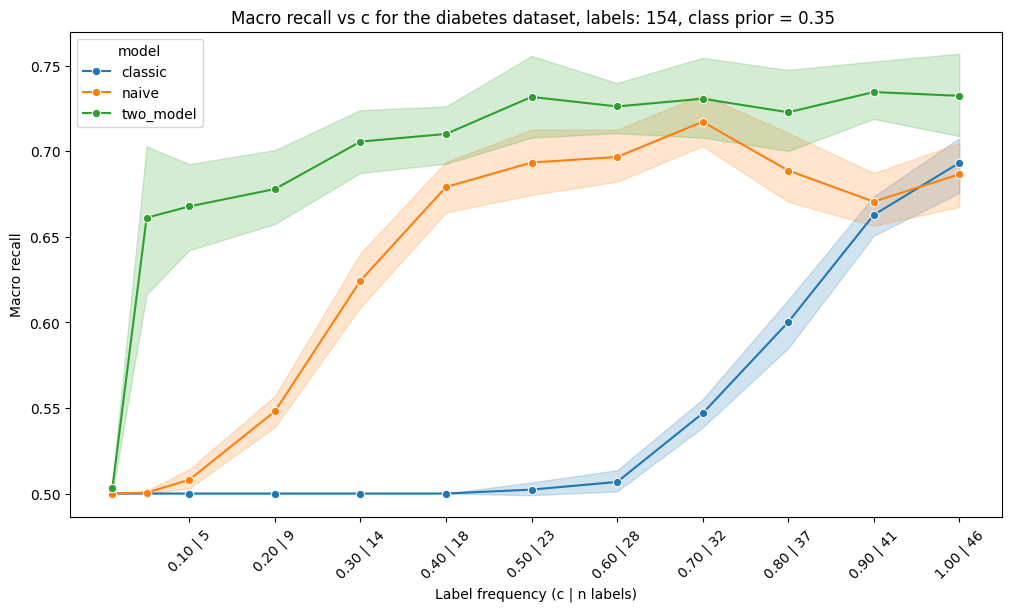

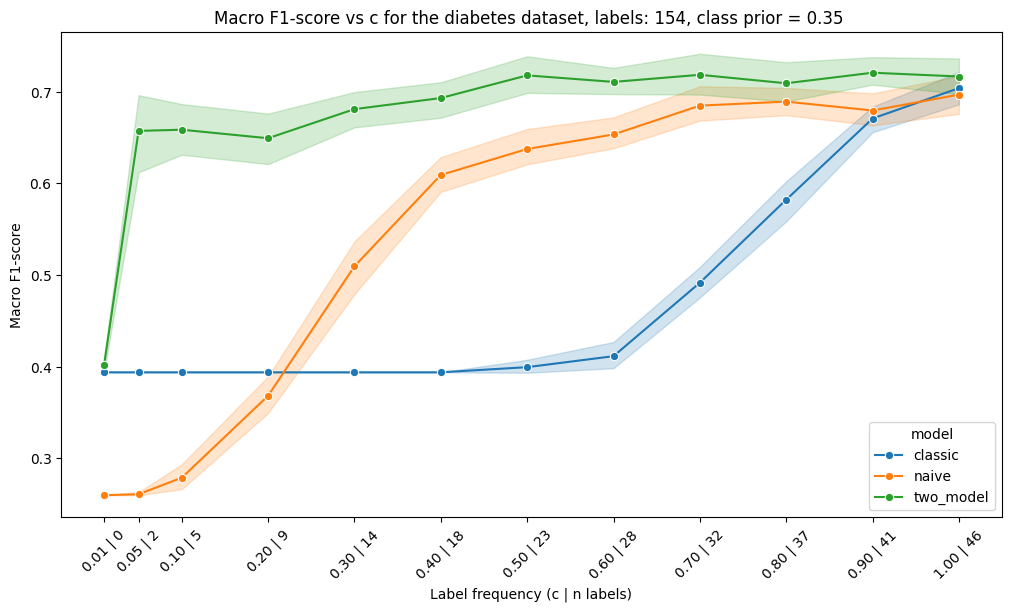

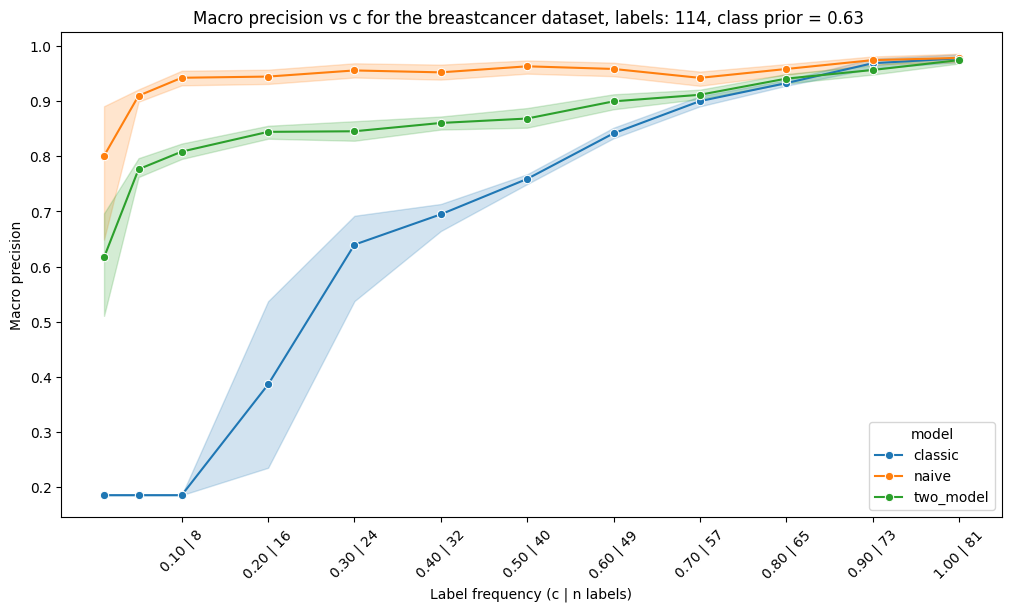

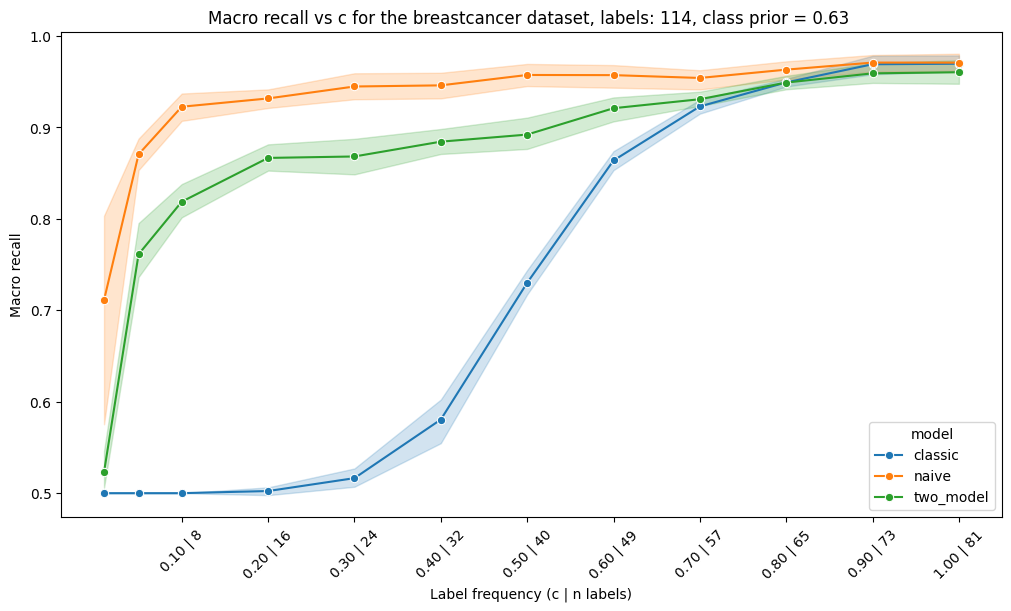

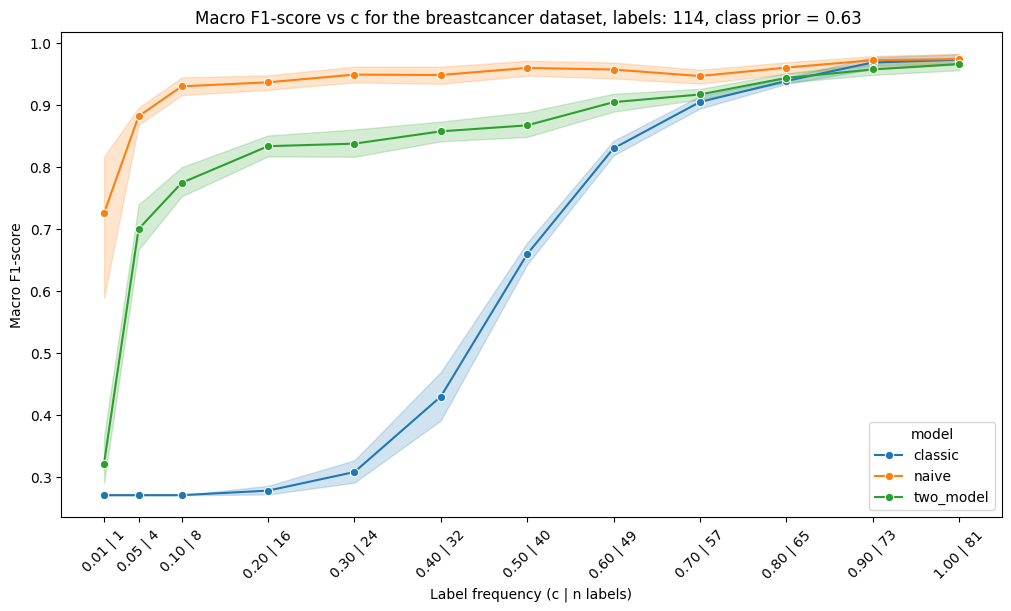

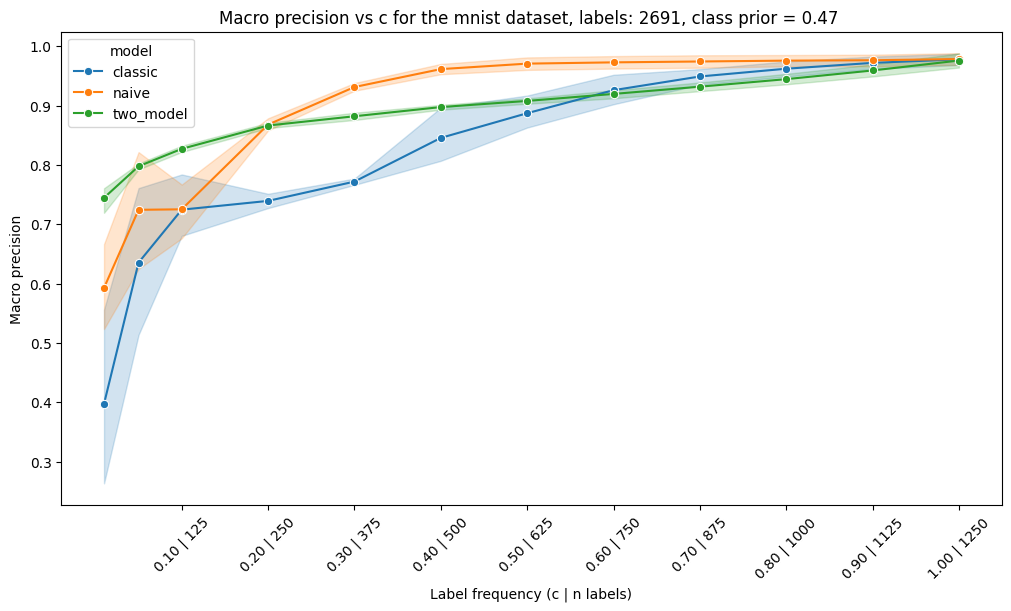

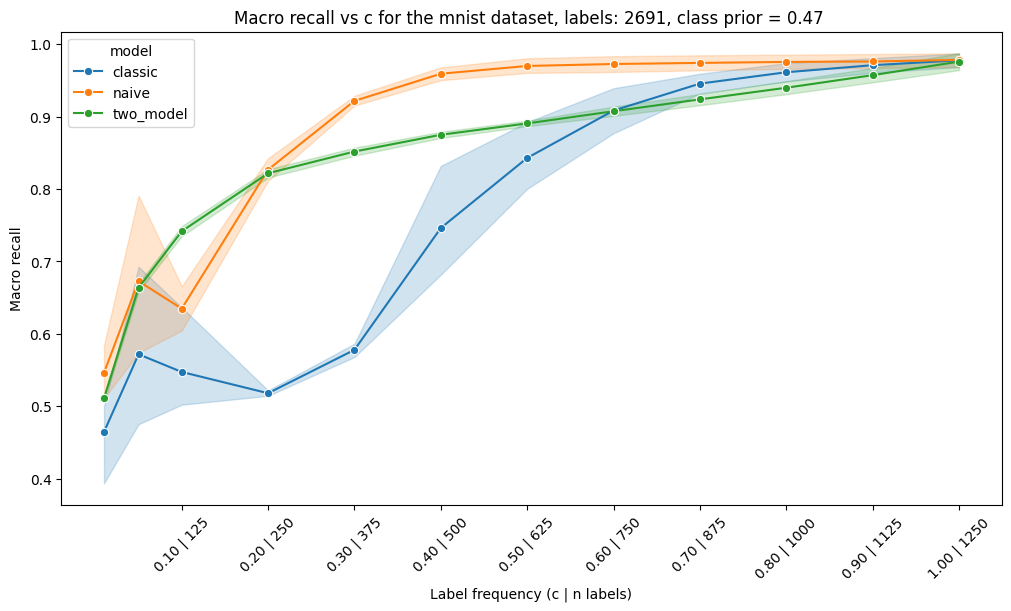

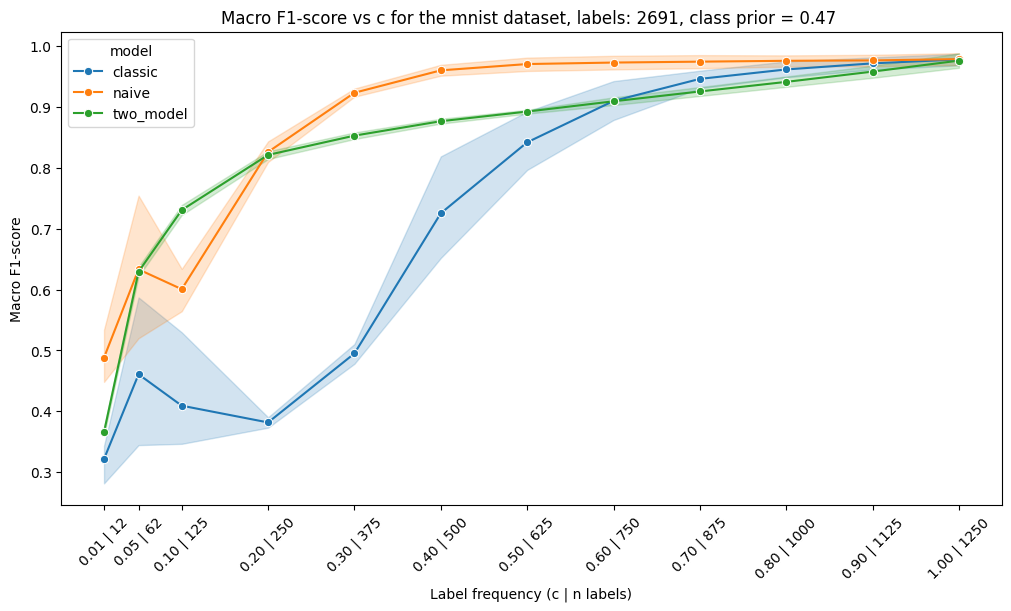

In [10]:

for dataset in df["dataset"].unique():
    assert dataset in ["mock","diabetes","breastcancer","mnist"], f"Unknown dataset: {dataset}"
    c = df["c"].unique().tolist()
    n_labels = get_n_labels(dataset, df["c"].unique())
    ticks = [n_labels[val] for val in c]
    plt.figure(figsize=(10, 6),layout='constrained')
    sns.lineplot(data=df[df["dataset"]==dataset], x="c",y="precision",marker="o",hue="model")
    plt.title(f"Macro precision vs c for the {dataset} dataset, {n_labels['title']} ")
    plt.ylabel("Macro precision")
    plt.xticks(c[2:], ticks[2:],rotation=45)

    plt.xlabel("Label frequency (c | n labels)")
    plt.savefig(os.path.join(fig_folder,f"Precision_macro_{dataset}.png"))
    plt.show()

    plt.figure(figsize=(10, 6),layout='constrained')
    sns.lineplot(data=df[df["dataset"]==dataset], x="c",y="recall",marker="o",hue="model")
    plt.title(f"Macro recall vs c for the {dataset} dataset, {n_labels['title']} ")
    plt.ylabel("Macro recall")
    plt.xticks(c[2:], ticks[2:],rotation=45)
    plt.xlabel("Label frequency (c | n labels)")
    plt.savefig(os.path.join(fig_folder,f"Recall_macro_{dataset}.png"))
    plt.show()

    plt.figure(figsize=(10, 6),layout='constrained')
    sns.lineplot(data=df[df["dataset"]==dataset], x="c",y="f1",marker="o",hue="model")
    plt.title(f"Macro F1-score vs c for the {dataset} dataset, {n_labels['title']} ")
    plt.ylabel("Macro F1-score")
    plt.xticks(c, ticks,rotation=45)
    plt.xlabel("Label frequency (c | n labels)")
    plt.savefig(os.path.join(fig_folder,f"F1_1_{dataset}.png"))
    plt.show()
